In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
data = pd.read_csv("./data/wine_train.csv")
data

,와인_종류,알코올_도수,사과산_함량,재_함량,재의_알칼리도,마그네슘_함량,총_페놀_함량,플라보노이드_함량,비플라보노이드_페놀_함량,프로안토시아닌_함량,색_강도,색조,희석_와인의_투과율_OD280_OD315,프롤린_함량
0,1,13.76,1.53,2.70,19.5,132,2.95,2.74,0.50,1.35,5.40,1.25,3.00,1235
1,2,12.67,0.98,2.24,18.0,99,2.20,1.94,0.30,1.46,2.62,1.23,3.16,450
2,1,13.58,1.66,2.36,19.1,106,2.86,3.19,0.22,1.95,6.90,1.09,2.88,1515
3,2,13.86,1.51,2.67,25.0,86,2.95,2.86,0.21,1.87,3.38,1.36,3.16,410
4,1,13.05,2.05,3.22,25.0,124,2.63,2.68,0.47,1.92,3.58,1.13,3.20,830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,2,12.43,1.53,2.29,21.5,86,2.74,3.15,0.39,1.77,3.94,0.69,2.84,352
102,3,12.20,3.03,2.32,19.0,96,1.25,0.49,0.40,0.73,5.50,0.66,1.83,510
103,1,13.51,1.80,2.65,19.0,110,2.35,2.53,0.29,1.54,4.20,1.10,2.87,1095
104,2,12.70,3.87,2.40,23.0,101,2.83,2.55,0.43,1.95,2.57,1.19,3.13,463


In [3]:
data['와인_종류'].value_counts()

와인_종류
2    42
1    35
3    29
Name: count, dtype: int64

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   와인_종류                   106 non-null    int64  
 1   알코올_도수                  106 non-null    float64
 2   사과산_함량                  106 non-null    float64
 3   재_함량                    106 non-null    float64
 4   재의_알칼리도                 106 non-null    float64
 5   마그네슘_함량                 106 non-null    int64  
 6   총_페놀_함량                 106 non-null    float64
 7   플라보노이드_함량               106 non-null    float64
 8   비플라보노이드_페놀_함량           106 non-null    float64
 9   프로안토시아닌_함량              106 non-null    float64
 10  색_강도                    106 non-null    float64
 11  색조                      106 non-null    float64
 12  희석_와인의_투과율_OD280_OD315  106 non-null    float64
 13  프롤린_함량                  106 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 11.7 KB


<Axes: >

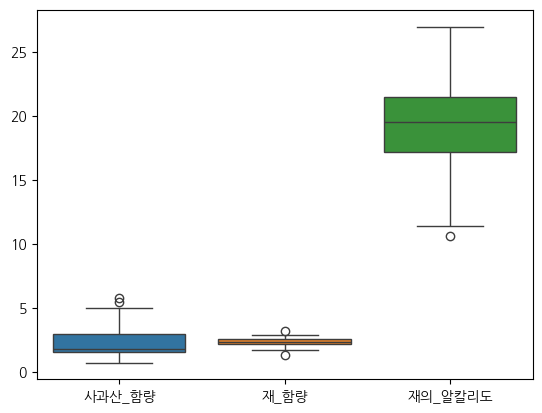

In [5]:
sns.boxplot(data.iloc[:,2:5])

<Axes: >

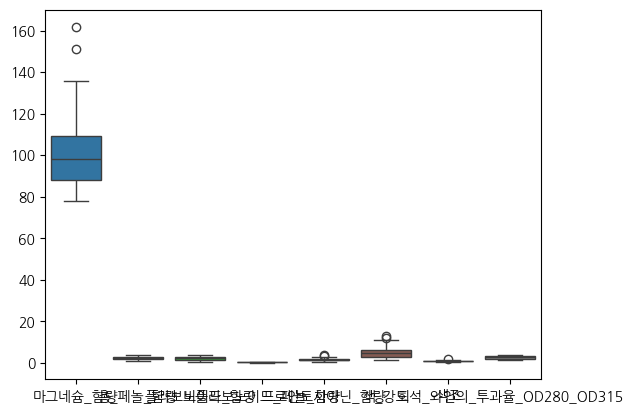

In [6]:
sns.boxplot(data.iloc[:,5:-1])

In [7]:
X = data.drop('와인_종류', axis=1)
y = data['와인_종류']

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [10]:
from sklearn.preprocessing import RobustScaler

In [11]:
rs = RobustScaler()
rs_X_train = rs.fit_transform(X_train)
rs_X_valid = rs.transform(X_valid)

# rs 변수에 있는 RobustScaler 저장 - joblib

In [12]:
import joblib

In [13]:
joblib.dump(rs, "./model/Robust_info.joblib")

['./model/Robust_info.joblib']

In [14]:
y_train.unique()

array([3, 2, 1])

# y 변수 레이블 인코딩

In [15]:
from sklearn.preprocessing import LabelEncoder

In [16]:
le = LabelEncoder()
le_y_train = le.fit_transform(y_train)
le_y_valid = le.transform(y_valid)

In [17]:
joblib.dump(le, "./model/labelencoder.joblib")

['./model/labelencoder.joblib']

# 딥러닝 모델 작성 및 훈련

In [24]:
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [26]:
rs_X_train.shape[1]

13

In [30]:
len(np.unique(le_y_train))

3

In [35]:
model = Sequential()
model.add(Input(shape=(rs_X_train.shape[1],)))
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(len(np.unique(le_y_train)), activation='softmax'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,123 (51.26 KB)

 Trainable params: 12,675 (49.51 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 850ms/step - accuracy: 0.4054 - loss: 1.4594 - val_accuracy: 0.5625 - val_loss: 1.0115
Epoch 2/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6081 - loss: 0.8763 - val_accuracy: 0.7188 - val_loss: 0.9643
Epoch 3/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6622 - loss: 0.7731 - val_accuracy: 0.8125 - val_loss: 0.9234
Epoch 4/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7432 - loss: 0.5471 - val_accuracy: 0.8750 - val_loss: 0.8900
Epoch 5/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8514 - loss: 0.4294 - val_accuracy: 0.9062 - val_loss: 0.8598
Epoch 6/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8108 - loss: 0.4802 - val_accuracy: 0.9062 - val_loss: 0.8342
Epoch 7/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.8919 - loss: 0.4068 - val_accuracy: 0.9062 - val_loss: 0.8084
Epoch 8/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8919 - loss: 0.3337 - val_accuracy: 0.9062 - 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0130 - val_accuracy: 0.9375 - val_loss: 0.1233
Epoch 102/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0185 - val_accuracy: 0.9375 - val_loss: 0.1268
Epoch 103/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0132 - val_accuracy: 0.9375 - val_loss: 0.1280
Epoch 104/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9865 - loss: 0.0319 - val_accuracy: 0.9375 - val_loss: 0.1266
Epoch 105/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9595 - loss: 0.1243 - val_accuracy: 0.9375 - val_loss: 0.1278
Epoch 106/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0172 - val_accuracy: 0.9375 - val_loss: 0.1281
Epoch 107/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9865 - loss: 0.0326 - val_accuracy: 0.9375 - val_loss: 0.1309
Epoch 108/1000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9865 - loss: 0.0385 - val_accuracy: 0.9375 - 

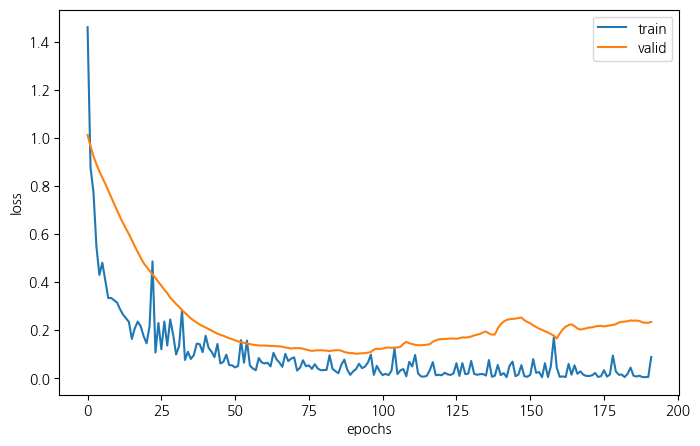

In [36]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
early_stop = EarlyStopping(patience=100, restore_best_weights=True)
file_path = "./model/red_wine_best_model.keras"
model_save = ModelCheckpoint(filepath=file_path, save_best_only=True)
history = model.fit(rs_X_train, le_y_train,
                   epochs=1000,
                   batch_size=16,
                   validation_data=(rs_X_valid, le_y_valid),
                   callbacks=[early_stop, model_save])
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'valid'])
plt.show()

머신러닝 모델 저장하기

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [38]:
scv = StratifiedKFold(shuffle=True, random_state=42)
params = dict(max_depth=[3,6,9,12,15],
             n_estimators=[100, 300, 500, 1000, 1500, 2000])
model= RandomForestClassifier(random_state=42, class_weight='balanced')
randcv = RandomizedSearchCV(n_iter=100, estimator=model, param_distributions=params,
                           cv=scv, random_state=42, n_jobs=-1)
randcv.fit(X_train, y_train)
print("best_estimator: ", randcv.best_estimator_)
print("best_params: ", randcv.best_params_)
val_pred2 = randcv.predict(X_valid)
print(classification_report(y_valid, val_pred2))

/home/haram/miniforge3/envs/tf/lib/python3.12/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 30 is smaller than n_iter=100. Running 30 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


best_estimator:  RandomForestClassifier(class_weight='balanced', max_depth=3, random_state=42)
best_params:  {'n_estimators': 100, 'max_depth': 3}
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        10
           2       1.00      0.92      0.96        13
           3       0.90      1.00      0.95         9

    accuracy                           0.97        32
   macro avg       0.97      0.97      0.97        32
weighted avg       0.97      0.97      0.97        32



In [40]:
joblib.dump(randcv, "./model/rfc_model.joblib")

['./model/rfc_model.joblib']